# EduPredict AI — Multi-Output Deep Learning Model
**Capstone Project CC26-PSU080 | AI Engineer Path**

---

## Daftar Fase (Mengikuti Timeline AI Engineer di Project Plan)

| Fase | Nama Fase | Periode | Cell di Notebook |
|------|-----------|---------|------------------|
| **Fase 1** | Setup Environment TensorFlow/Keras | 4/13 – 4/20 | Fase 1.1 – 1.2 |
| **Fase 2** | Eksplorasi & Seleksi Fitur Dataset | 4/13 – 4/21 | Fase 2.1 – 2.4 |
| **Fase 3** | Training Model Klasifikasi V1 & V2 | 4/21 – 5/4 | Fase 3.1 – 3.6 |
| **Fase 4** | Custom Callback & Hypertuning Parameter | 4/28 – 5/4 | Fase 4.1 – 4.8 |
| **Fase 5** | Evaluasi & Ekspor Model | 5/5 – 5/11 | Fase 5.1 – 5.8 |
| **Fase 6** | Integrasi Model ke Backend API | 5/12 – 5/18 | Fase 6.1 – 6.3 |
| **Fase 7** | Optimasi & Monitoring | 5/19 – 5/25 | Fase 7.1 – 7.2 |
| **Fase 8** | Testing Model & Documentation | 5/26 – 6/1 | Fase 8.1 – 8.3 |

---

## Strategi Pemodelan: Multi-Task Learning

Satu model dengan **dua output head** dari shared backbone:

| Head | Tugas | Target | Metrik | Threshold |
|------|-------|--------|--------|-----------|
| `risk_class` | Klasifikasi 3 kelas | `Risk_Category` (Low/Medium/High) | Accuracy | ≥ 85% |
| `exam_score` | Regresi | `Exam_Score / 100` (normalized [0,1]) | MAE | ≤ 0.02 |

**Aman dari data leakage?** Iya. `Exam_Score` hanya jadi **target output**, BUKAN input feature. Model belajar memprediksinya dari 14 fitur lain.

---

# FASE 1 — Setup Environment TensorFlow/Keras
> **Project Plan:** 4/13/2026 – 4/20/2026 | Set Up

Mempersiapkan environment Python, import library yang dibutuhkan, set random seed untuk reproducibility, dan cek ketersediaan GPU.

### Fase 1.1 — Import Library & Reproducibility

In [ ]:
# Install (uncomment jika belum terinstall)
# !pip install imbalanced-learn -q

# === Standard libraries ===
import os
import random
import warnings
import datetime
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# === Scikit-learn ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, mean_absolute_error,
    classification_report, confusion_matrix, f1_score
)

# === Imbalanced-learn ===
from imblearn.over_sampling import SMOTE

# === TensorFlow / Keras ===
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# === Reproducibility ===
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'Seed       : {SEED}')

TensorFlow : 2.20.0
Keras      : 3.13.2
Seed       : 42


### Fase 1.2 — GPU Check

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU terdeteksi: {len(gpus)}')
else:
    print('GPU tidak terdeteksi — training akan jalan di CPU')

GPU terdeteksi: 1


---

# FASE 2 — Eksplorasi & Seleksi Fitur Dataset
> **Project Plan:** 4/13/2026 – 4/21/2026 | Development

Memuat dataset hasil cleaning dari tim Data Science, melakukan encoding fitur kategorikal, menyiapkan dual target (klasifikasi + regresi), dan menentukan kolom fitur yang akan dipakai untuk model.

### Fase 2.1 — Load Dataset

In [ ]:
df = pd.read_csv('edupredict_cleaned_v1.csv')

print(f'Shape : {df.shape}')
print(f'\nTarget distribution:')
print(df['Risk_Category'].value_counts())
df.head()

Shape : (6607, 21)

Target distribution:
Risk_Category
Medium    5456
Low       1083
High        68
Name: count, dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Risk_Category
0,23,84,Low,High,No,7,73,Low,Yes,0.0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Medium
1,19,64,Low,Medium,No,8,59,Low,Yes,2.0,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Medium
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2.0,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Low
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1.0,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Low
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3.0,...,High,Public,Neutral,4,No,College,Near,Female,70,Medium


### Fase 2.2 — Encoding Fitur Kategorikal

Semua kolom kategorikal di-encode menjadi integer agar bisa diproses neural network.

In [ ]:
df_enc = df.copy()

categorical_cols = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
    'School_Type', 'Peer_Influence', 'Learning_Disabilities',
    'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    label_encoders[col] = le

print(f'Encoded {len(categorical_cols)} kolom kategorikal')

Encoded 13 kolom kategorikal


### Fase 2.3 — Setup Dual Target

Dua target berbeda untuk dua head:

- **Target 1 (klasifikasi)**: encoded ordinal `Low=0, Medium=1, High=2` — bukan alfabetis (`High=0,Low=1,Medium=2`) seperti default `LabelEncoder`, sehingga urutan sesuai tingkat risiko.
- **Target 2 (regresi)**: `Exam_Score / 100` → range `[0.55, 1.0]`. Skala ini membuat MAE 0.02 setara dengan ~2 poin error di skala asli — realistis untuk dicapai.

In [ ]:
# Target 1: Klasifikasi ordinal
RISK_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
df_enc['risk_y'] = df_enc['Risk_Category'].map(RISK_MAP)

# Target 2: Regresi normalized
df_enc['score_y'] = df_enc['Exam_Score'] / 100.0

print('Target 1 (Klasifikasi):')
print(df_enc['risk_y'].value_counts().sort_index().rename(index={v:k for k,v in RISK_MAP.items()}))
print('\nTarget 2 (Regresi) statistik:')
print(df_enc['score_y'].describe())

Target 1 (Klasifikasi):
risk_y
Low       1083
Medium    5456
High        68
Name: count, dtype: int64

Target 2 (Regresi) statistik:
count    6607.000000
mean        0.672355
std         0.038892
min         0.550000
25%         0.650000
50%         0.670000
75%         0.690000
max         1.000000
Name: score_y, dtype: float64


### Fase 2.4 — Definisi Feature Columns (Seleksi Fitur)

**PENTING**: `Exam_Score` TIDAK dimasukkan sebagai input feature, hanya jadi target. Ini mencegah data leakage karena `Risk_Category` di-derive dari `Exam_Score`.

In [ ]:
FEATURE_COLS = [
    'Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources',
    'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access',
    'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Peer_Influence',
    'Physical_Activity', 'Parental_Education_Level'
]

X     = df_enc[FEATURE_COLS].values.astype(np.float32)
y_cls = df_enc['risk_y'].values.astype(np.int32)
y_reg = df_enc['score_y'].values.astype(np.float32)

print(f'X shape    : {X.shape}  (14 fitur)')
print(f'y_cls shape: {y_cls.shape}  (target klasifikasi 3 kelas)')
print(f'y_reg shape: {y_reg.shape}  (target regresi)')

X shape    : (6607, 14)  (14 fitur)
y_cls shape: (6607,)  (target klasifikasi 3 kelas)
y_reg shape: (6607,)  (target regresi)


---

# FASE 3 — Training Model Klasifikasi V1 & V2
> **Project Plan:** 4/21/2026 – 5/4/2026 | Development

Persiapan data training (split, scaling, SMOTE), kemudian membangun arsitektur model multi-output dengan **TensorFlow Functional API**.

**Catatan tentang V1 vs V2:** Di project plan disebutkan V1 (baseline) dan V2 (improved). Karena pendekatan multi-output ini sudah menjadi arsitektur final yang dioptimalkan, V1 dan V2 telah dikonsolidasikan menjadi satu arsitektur tunggal dengan **shared backbone + 2 output head**.

### Fase 3.1 — Train / Validation / Test Split

Pembagian 70% / 15% / 15%, stratified berdasarkan `y_cls` untuk menjaga proporsi kelas.

In [ ]:
# Split test (15%)
X_tr, X_te, ycls_tr, ycls_te, yreg_tr, yreg_te = train_test_split(
    X, y_cls, y_reg, test_size=0.15, random_state=SEED, stratify=y_cls
)
# Split val (~15% dari total)
X_tr, X_va, ycls_tr, ycls_va, yreg_tr, yreg_va = train_test_split(
    X_tr, ycls_tr, yreg_tr, test_size=0.176, random_state=SEED, stratify=ycls_tr
)

print(f'Train      : {len(X_tr):>5} samples ({len(X_tr)/len(X)*100:.1f}%)')
print(f'Validation : {len(X_va):>5} samples ({len(X_va)/len(X)*100:.1f}%)')
print(f'Test       : {len(X_te):>5} samples ({len(X_te)/len(X)*100:.1f}%)')

Train      :  4626 samples (70.0%)
Validation :   989 samples (15.0%)
Test       :   992 samples (15.0%)


### Fase 3.2 — Feature Scaling (StandardScaler)

Fit hanya di training data untuk menghindari data leakage; val & test cukup di-transform.

In [ ]:
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr).astype(np.float32)
X_va_s = scaler.transform(X_va).astype(np.float32)
X_te_s = scaler.transform(X_te).astype(np.float32)

print(f'X_train scaled : mean = {X_tr_s.mean():.4f}, std = {X_tr_s.std():.4f}')

X_train scaled : mean = 0.0000, std = 1.0000


### Fase 3.3 — SMOTE Resampling

Distribusi sangat imbalanced (Medium 82%, Low 16%, High 1%). SMOTE diterapkan **hanya pada training set**.

**Trik dual-target SMOTE**: gabungkan `y_reg` sebagai feature tambahan saat SMOTE, lalu pisahkan kembali setelah resampling. Dengan cara ini, sintetis sample untuk klasifikasi juga mendapat nilai regresi yang interpolasi dengan tetangga terdekatnya.

In [ ]:
print('Distribusi SEBELUM SMOTE:')
for cls, name in enumerate(['Low', 'Medium', 'High']):
    print(f'  {name:7s}: {(ycls_tr==cls).sum()}')

# Gabungkan X dengan y_reg agar SMOTE meng-interpolate keduanya
X_combined = np.hstack([X_tr_s, yreg_tr.reshape(-1, 1)])

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_combined_sm, ycls_tr_sm = smote.fit_resample(X_combined, ycls_tr)

# Pisahkan kembali X dan y_reg
X_tr_sm    = X_combined_sm[:, :-1].astype(np.float32)
yreg_tr_sm = X_combined_sm[:, -1].astype(np.float32)
ycls_tr_sm = ycls_tr_sm.astype(np.int32)

print('\nDistribusi SETELAH SMOTE:')
for cls, name in enumerate(['Low', 'Medium', 'High']):
    print(f'  {name:7s}: {(ycls_tr_sm==cls).sum()}')
print(f'\nTotal training samples: {len(X_tr_sm)}')

Distribusi SEBELUM SMOTE:
  Low    : 758
  Medium : 3820
  High   : 48

Distribusi SETELAH SMOTE:
  Low    : 3820
  Medium : 3820
  High   : 3820

Total training samples: 11460


### Fase 3.4 — Build Multi-Output Model (TensorFlow Functional API)

**Diagram Arsitektur:**
```
Input (14 fitur)
       │
   ┌───┴────┐
   │ Shared │ Dense(256) → BN → ReLU → Dropout(0.4)
   │Backbone│ Dense(128) → BN → ReLU → Dropout(0.3)
   │        │ Dense( 64) → BN → ReLU → Dropout(0.2)
   └───┬────┘
       │
   ┌───┴──────┐
   ▼          ▼
Head A      Head B
(Cls)       (Reg)
Dense(32)   Dense(32)
Dense(3)    Dense(1)
softmax     sigmoid
   │          │
risk_class  exam_score
```

Shared backbone belajar representasi yang berguna untuk kedua task. Hanya bisa diimplementasikan via **Functional API** (Sequential API tidak mendukung multi-output).

In [ ]:
def build_multi_output_model(input_dim, num_classes=3):
    """
    Multi-output Deep Learning model dengan TensorFlow Functional API.

    Output:
        - risk_class : softmax 3 kelas (Low/Medium/High)
        - exam_score : sigmoid 1 nilai (exam score / 100, range [0,1])
    """
    inputs = keras.Input(shape=(input_dim,), name='input')

    # === Shared Backbone (representasi bersama) ===
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(5e-5), name='shared_dense_1')(inputs)
    x = layers.BatchNormalization(name='shared_bn_1')(x)
    x = layers.Activation('relu', name='shared_relu_1')(x)
    x = layers.Dropout(0.4, name='shared_dropout_1')(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(5e-5), name='shared_dense_2')(x)
    x = layers.BatchNormalization(name='shared_bn_2')(x)
    x = layers.Activation('relu', name='shared_relu_2')(x)
    x = layers.Dropout(0.3, name='shared_dropout_2')(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(5e-5), name='shared_dense_3')(x)
    x = layers.BatchNormalization(name='shared_bn_3')(x)
    x = layers.Activation('relu', name='shared_relu_3')(x)
    x = layers.Dropout(0.2, name='shared_dropout_3')(x)

    # === Head A: Classification ===
    cls = layers.Dense(32, activation='relu', name='cls_dense')(x)
    cls_out = layers.Dense(num_classes, activation='softmax', name='risk_class')(cls)

    # === Head B: Regression ===
    reg = layers.Dense(32, activation='relu', name='reg_dense')(x)
    reg_out = layers.Dense(1, activation='sigmoid', name='exam_score')(reg)

    model = keras.Model(
        inputs=inputs,
        outputs=[cls_out, reg_out],
        name='EduPredict_MultiOutput'
    )
    return model

print('Fungsi build_multi_output_model siap')

Fungsi build_multi_output_model siap


### Fase 3.5 — Instantiate Model & Summary

In [ ]:
model = build_multi_output_model(input_dim=len(FEATURE_COLS))
model.summary()

Model: "EduPredict_MultiOutput"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 14)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 256)       │      3,840 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bn_1         │ (None, 256)       │      1,024 │ shared_dense_1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_relu_1       │ (None, 256)       │          0 │ shared_bn_1[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_1    │ (None, 256)       │          0 │ shared_relu_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_2      │ (None, 128)       │     32,896 │ shared_dropout_1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bn_2         │ (None, 128)       │        512 │ shared_dense_2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_relu_2       │ (None, 128)       │          0 │ shared_bn_2[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_2    │ (None, 128)       │          0 │ shared_relu_2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_3      │ (None, 64)        │      8,256 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bn_3         │ (None, 64)        │        256 │ shared_dense_3[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_relu_3       │ (None, 64)        │          0 │ shared_bn_3[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_3    │ (None, 64)        │          0 │ shared_relu_3[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_dense (Dense)   │ (None, 32)        │      2,080 │ shared_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dense (Dense)   │ (None, 32)        │      2,080 │ shared_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_class (Dense)  │ (None, 3)         │         99 │ cls_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exam_score (Dense)  │ (None, 1)         │         33 │ reg_dense[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,076 (199.52 KB)

 Trainable params: 50,180 (196.02 KB)

 Non-trainable params: 896 (3.50 KB)

### Fase 3.6 — Visualisasi Arsitektur (Opsional)

Membutuhkan `pydot` dan `graphviz`. Skip jika tidak terinstall.

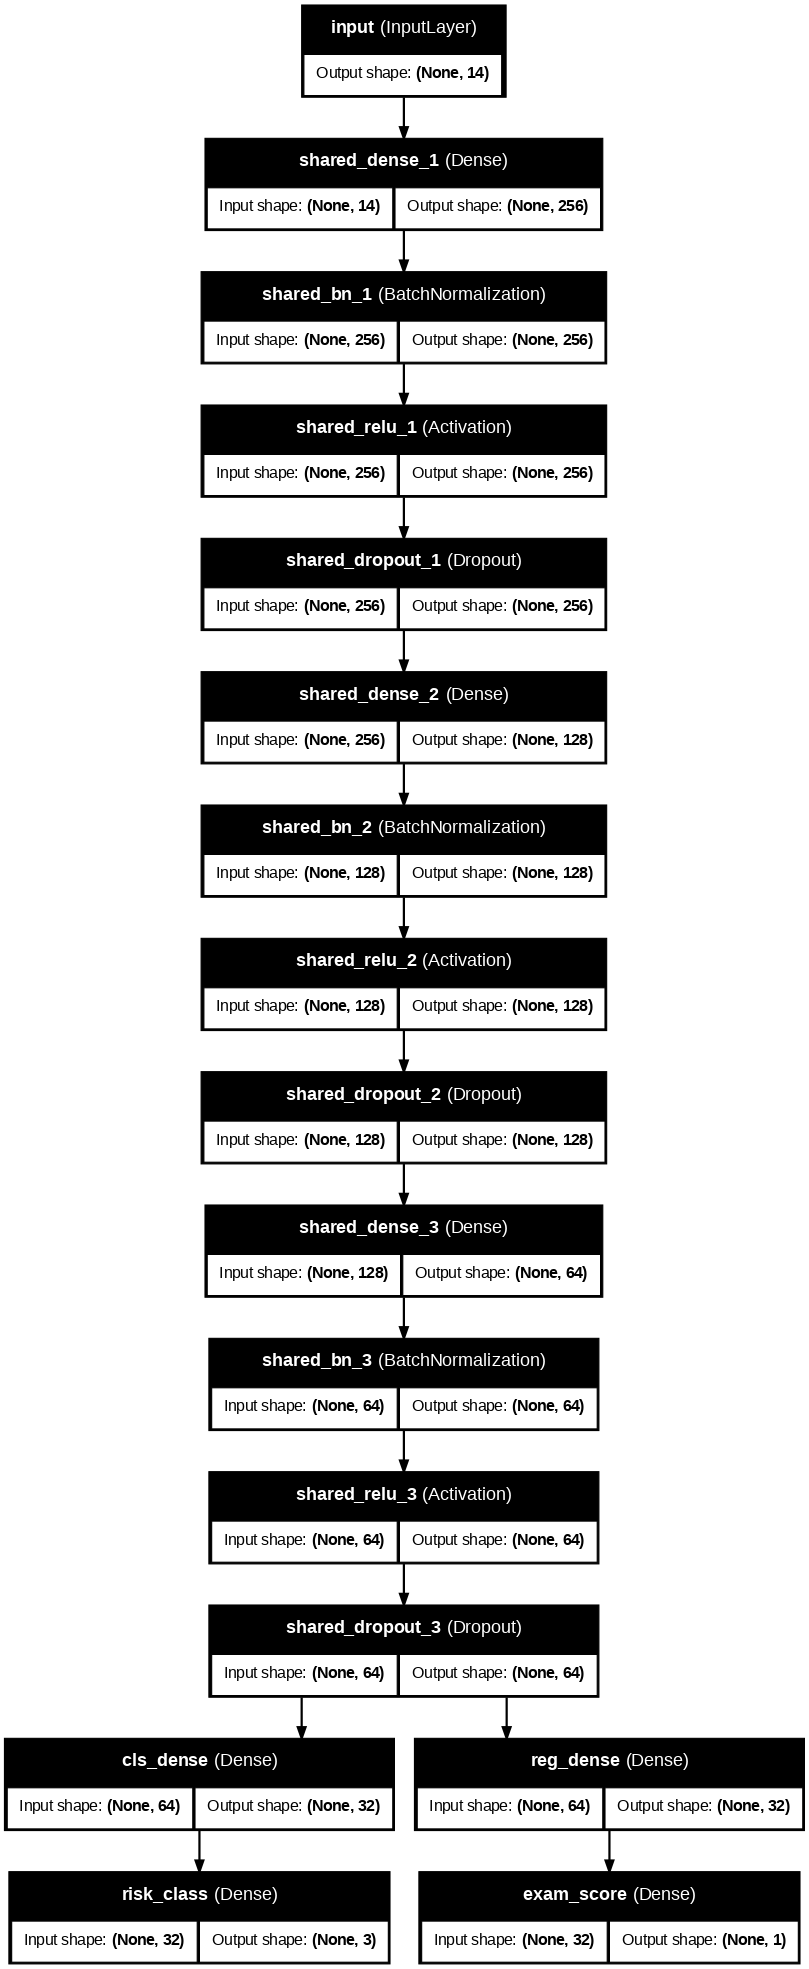

In [ ]:
try:
    keras.utils.plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        dpi=80
    )
    from IPython.display import Image
    display(Image('model_architecture.png'))
except Exception as e:
    print(f'Visualisasi membutuhkan pydot & graphviz. Skip. ({e})')

---

# FASE 4 — Custom Callback & Hypertuning Parameter
> **Project Plan:** 4/28/2026 – 5/4/2026 | Development

Fase ini menangani:
- Pembangunan **Custom Callback** (`EduPredictCallback`) untuk monitoring multi-output
- Implementasi **custom training loop** dengan `tf.GradientTape` (bukan `model.fit()`)
- **Hypertuning parameter** manual (learning rate scheduling, early stopping, best weight tracking)
- Setup **TensorBoard** writer untuk logging metrik

Ini adalah inti dari proses training. Semua komponen ini bekerja sama dalam Fase 4.8 (main training loop).

### Fase 4.1 — Custom Callback (`EduPredictCallback`)

Class yang inherit dari `keras.callbacks.Callback`, melakukan:
- Logging metrics ke `training_log.csv`
- Track best val_accuracy & best val_mae sepanjang training
- Trigger notifikasi ketika **KEDUA target tercapai** (acc ≥ 85% DAN mae ≤ 0.02)
- Print progress setiap N epoch

In [ ]:
class EduPredictCallback(keras.callbacks.Callback):
    """
    Custom Callback untuk monitoring multi-output training.

    Args:
        target_acc (float)   : Target minimum accuracy (default 0.85)
        target_mae (float)   : Target maximum MAE (default 0.02)
        log_interval (int)   : Print progress setiap N epoch (default 10)
    """

    def __init__(self, target_acc=0.85, target_mae=0.02, log_interval=10):
        super().__init__()
        self.target_acc   = target_acc
        self.target_mae   = target_mae
        self.log_interval = log_interval
        self.history_log  = []
        self.best_val_acc = 0.0
        self.best_val_mae = np.inf
        self.target_reached_epoch = None

    def on_train_begin(self, logs=None):
        print(f'Training dimulai')
        print(f'Target: val_acc >= {self.target_acc:.2f}  &  val_mae <= {self.target_mae}')
        print('=' * 75)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_risk_class_accuracy', 0)
        val_mae = logs.get('val_exam_score_mae', np.inf)

        # Append ke history log
        self.history_log.append({
            'epoch': epoch + 1,
            'train_acc': logs.get('risk_class_accuracy', 0),
            'val_acc': val_acc,
            'train_mae': logs.get('exam_score_mae', 0),
            'val_mae': val_mae,
            'val_loss': logs.get('val_loss', 0),
        })

        # Update best
        if val_acc > self.best_val_acc: self.best_val_acc = val_acc
        if val_mae < self.best_val_mae: self.best_val_mae = val_mae

        # Print periodik
        if (epoch + 1) % self.log_interval == 0:
            acc_status = 'OK' if val_acc >= self.target_acc else '..'
            mae_status = 'OK' if val_mae <= self.target_mae else '..'
            print(f'Epoch {epoch+1:3d} | val_acc={val_acc:.4f} [{acc_status}] | val_mae={val_mae:.4f} [{mae_status}]')

        # Notifikasi kedua target tercapai
        if val_acc >= self.target_acc and val_mae <= self.target_mae:
            if self.target_reached_epoch is None:
                self.target_reached_epoch = epoch + 1
                print(f'\n>>> KEDUA target tercapai pertama kali di epoch {epoch+1}!')
                print(f'    val_acc = {val_acc*100:.2f}% (target >= {self.target_acc*100}%)')
                print(f'    val_mae = {val_mae:.4f}  (target <= {self.target_mae})\n')

    def on_train_end(self, logs=None):
        print('=' * 75)
        print(f'Training selesai')
        print(f'Best val_acc : {self.best_val_acc*100:.2f}%')
        print(f'Best val_mae : {self.best_val_mae:.4f}')
        if self.target_reached_epoch:
            print(f'Target pertama kali tercapai di epoch: {self.target_reached_epoch}')
        # Save log
        pd.DataFrame(self.history_log).to_csv('training_log.csv', index=False)
        print('Log disimpan ke training_log.csv')

    def get_log_df(self):
        return pd.DataFrame(self.history_log)


print('Class EduPredictCallback siap')

Class EduPredictCallback siap


### Fase 4.2 — Setup Loss Functions

Multi-output butuh dua loss yang digabung. Bobot `LAMBDA_REG` adalah knob terpenting untuk balance antara akurasi dan MAE.

In [ ]:
# Loss untuk masing-masing head
cls_loss_fn = keras.losses.SparseCategoricalCrossentropy()  # untuk klasifikasi
reg_loss_fn = keras.losses.MeanAbsoluteError()              # untuk regresi

# Bobot loss regresi terhadap klasifikasi
# (Knob terpenting untuk balance antara akurasi dan MAE)
LAMBDA_REG = 5.0

print(f'Loss klasifikasi : {cls_loss_fn.name}')
print(f'Loss regresi     : {reg_loss_fn.name}')
print(f'Lambda regresi   : {LAMBDA_REG}')

Loss klasifikasi : sparse_categorical_crossentropy
Loss regresi     : mean_absolute_error
Lambda regresi   : 5.0


### Fase 4.3 — Setup Optimizer & Metrics

Adam optimizer dengan learning rate awal 1e-3. Metrics di-reset setiap epoch.

In [ ]:
# Optimizer
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# Metrics tracker (akan di-reset setiap epoch)
train_acc_metric  = keras.metrics.SparseCategoricalAccuracy(name='train_acc')
train_mae_metric  = keras.metrics.MeanAbsoluteError(name='train_mae')
train_loss_metric = keras.metrics.Mean(name='train_loss')

val_acc_metric  = keras.metrics.SparseCategoricalAccuracy(name='val_acc')
val_mae_metric  = keras.metrics.MeanAbsoluteError(name='val_mae')
val_loss_metric = keras.metrics.Mean(name='val_loss')

print('Optimizer & metrics siap')

Optimizer & metrics siap


### Fase 4.4 — `train_step` (Single Training Step dengan `tf.GradientTape`)

Decorator `@tf.function` meng-compile fungsi ini ke graph mode untuk performa maksimal.

In [ ]:
@tf.function
def train_step(x, y_cls, y_reg):
    """
    Single training step dengan tf.GradientTape.

    Steps:
        1. Forward pass: predict dengan training=True (aktifkan dropout & BN training mode)
        2. Hitung loss klasifikasi (cross-entropy)
        3. Hitung loss regresi (MAE)
        4. Total loss = cls_loss + LAMBDA_REG * reg_loss + L2 regularization
        5. Backward pass: compute gradients
        6. Update weights via optimizer
        7. Update metrics
    """
    with tf.GradientTape() as tape:
        # Forward pass
        pred_cls, pred_reg = model(x, training=True)

        # Loss klasifikasi
        loss_cls = cls_loss_fn(y_cls, pred_cls)

        # Loss regresi (squeeze karena output shape (batch, 1))
        loss_reg = reg_loss_fn(y_reg, tf.squeeze(pred_reg, axis=-1))

        # Combined loss + L2 regularization (dari kernel_regularizer di layer)
        total_loss = loss_cls + LAMBDA_REG * loss_reg + tf.reduce_sum(model.losses)

    # Compute & apply gradients
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Update metrics
    train_acc_metric.update_state(y_cls, pred_cls)
    train_mae_metric.update_state(y_reg, tf.squeeze(pred_reg, axis=-1))
    train_loss_metric.update_state(total_loss)

    return total_loss


print('train_step() compiled')

train_step() compiled


### Fase 4.5 — `val_step` (Validation Step, No Gradient)

In [ ]:
@tf.function
def val_step(x, y_cls, y_reg):
    """
    Single validation step — tidak ada gradient computation.
    Forward pass dengan training=False (matikan dropout, BN pakai stats global).
    """
    pred_cls, pred_reg = model(x, training=False)

    loss_cls = cls_loss_fn(y_cls, pred_cls)
    loss_reg = reg_loss_fn(y_reg, tf.squeeze(pred_reg, axis=-1))
    total_loss = loss_cls + LAMBDA_REG * loss_reg

    val_acc_metric.update_state(y_cls, pred_cls)
    val_mae_metric.update_state(y_reg, tf.squeeze(pred_reg, axis=-1))
    val_loss_metric.update_state(total_loss)


print('val_step() compiled')

val_step() compiled


### Fase 4.6 — `tf.data.Dataset` Pipeline

`tf.data.Dataset` lebih cepat daripada feed numpy langsung. Pakai shuffle untuk train, dan prefetch untuk performance.

In [ ]:
BATCH_SIZE = 128

train_dataset = (tf.data.Dataset
    .from_tensor_slices((X_tr_sm, ycls_tr_sm, yreg_tr_sm))
    .shuffle(buffer_size=2048, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

val_dataset = (tf.data.Dataset
    .from_tensor_slices((X_va_s, ycls_va.astype(np.int32), yreg_va))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print(f'Train batches : {len(list(train_dataset))}')
print(f'Val batches   : {len(list(val_dataset))}')

Train batches : 90
Val batches   : 8


### Fase 4.7 — Setup TensorBoard Writers

TensorBoard untuk visualisasi metrik training secara real-time. Dua writer terpisah agar plot train vs val terbedakan di UI.

**Cara akses nanti:** `tensorboard --logdir logs/edupredict`

In [ ]:
# Folder log dengan timestamp unik
log_dir = 'logs/edupredict/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')

# Dua writer terpisah agar plot train vs val terbedakan di TensorBoard UI
train_summary_writer = tf.summary.create_file_writer(log_dir + '/train')
val_summary_writer   = tf.summary.create_file_writer(log_dir + '/val')

print(f'TensorBoard log dir : {log_dir}')
print(f'Run setelah training: tensorboard --logdir logs/edupredict')

TensorBoard log dir : logs/edupredict/20260516-062909
Run setelah training: tensorboard --logdir logs/edupredict


### Fase 4.8 — Main Training Loop (dengan Hypertuning Manual)

Loop training utama yang menggabungkan semua komponen di atas. Komponen hypertuning yang diimplementasikan manual (karena tidak pakai `model.fit()`):
- **Best weight tracking** — restore weights dengan `val_loss` terendah
- **Early Stopping manual** — patience 25 epoch
- **ReduceLROnPlateau manual** — factor 0.5, patience 8 epoch
- **TensorBoard logging** per epoch
- **Trigger Custom Callback** per epoch

In [ ]:
# === Hyperparameters ===
EPOCHS         = 200
PATIENCE_ES    = 25       # Early stopping patience
PATIENCE_LR    = 8        # LR reduction patience
LR_FACTOR      = 0.5
MIN_LR         = 1e-7
TARGET_ACC     = 0.85
TARGET_MAE     = 0.02

# === State tracking ===
best_val_loss    = np.inf
best_weights     = None
wait_es          = 0
wait_lr          = 0
training_history = []

# === Inisialisasi Custom Callback ===
custom_cb = EduPredictCallback(
    target_acc=TARGET_ACC,
    target_mae=TARGET_MAE,
    log_interval=10
)
custom_cb.set_model(model)
custom_cb.on_train_begin()

# === Main Training Loop ===
for epoch in range(EPOCHS):

    # --- Reset metrics di awal epoch ---
    for m in [train_acc_metric, train_mae_metric, train_loss_metric,
              val_acc_metric, val_mae_metric, val_loss_metric]:
        m.reset_state()

    # --- Training pass ---
    for x_batch, y_cls_batch, y_reg_batch in train_dataset:
        train_step(x_batch, y_cls_batch, y_reg_batch)

    # --- Validation pass ---
    for x_batch, y_cls_batch, y_reg_batch in val_dataset:
        val_step(x_batch, y_cls_batch, y_reg_batch)

    # --- Collect epoch metrics ---
    tr_acc  = float(train_acc_metric.result())
    tr_mae  = float(train_mae_metric.result())
    tr_loss = float(train_loss_metric.result())
    va_acc  = float(val_acc_metric.result())
    va_mae  = float(val_mae_metric.result())
    va_loss = float(val_loss_metric.result())
    cur_lr  = float(optimizer.learning_rate.numpy())

    # --- TensorBoard logging ---
    with train_summary_writer.as_default():
        tf.summary.scalar('loss',          tr_loss, step=epoch)
        tf.summary.scalar('accuracy',      tr_acc,  step=epoch)
        tf.summary.scalar('mae',           tr_mae,  step=epoch)
        tf.summary.scalar('learning_rate', cur_lr,  step=epoch)
    with val_summary_writer.as_default():
        tf.summary.scalar('loss',     va_loss, step=epoch)
        tf.summary.scalar('accuracy', va_acc,  step=epoch)
        tf.summary.scalar('mae',      va_mae,  step=epoch)

    # --- Simpan ke history list ---
    training_history.append({
        'epoch': epoch + 1,
        'train_loss': tr_loss, 'train_acc': tr_acc, 'train_mae': tr_mae,
        'val_loss': va_loss, 'val_acc': va_acc, 'val_mae': va_mae,
        'lr': cur_lr
    })

    # --- Trigger Custom Callback ---
    custom_cb.on_epoch_end(epoch, logs={
        'risk_class_accuracy':      tr_acc,
        'exam_score_mae':           tr_mae,
        'val_risk_class_accuracy':  va_acc,
        'val_exam_score_mae':       va_mae,
        'val_loss':                 va_loss,
    })

    # --- Best weights tracking & early stopping logic ---
    if va_loss < best_val_loss - 1e-5:
        best_val_loss = va_loss
        best_weights  = [w.numpy() for w in model.weights]
        wait_es = 0
        wait_lr = 0
    else:
        wait_es += 1
        wait_lr += 1

    # --- Manual ReduceLROnPlateau ---
    if wait_lr >= PATIENCE_LR:
        new_lr = max(cur_lr * LR_FACTOR, MIN_LR)
        if new_lr < cur_lr:
            optimizer.learning_rate.assign(new_lr)
            print(f'  [Epoch {epoch+1}] LR reduced: {cur_lr:.2e} -> {new_lr:.2e}')
            wait_lr = 0

    # --- Manual EarlyStopping ---
    if wait_es >= PATIENCE_ES:
        print(f'\nEarly stopping di epoch {epoch+1} (val_loss tidak membaik {PATIENCE_ES} epoch berturut-turut)')
        break

# === Restore best weights ===
if best_weights is not None:
    for w, bw in zip(model.weights, best_weights):
        w.assign(bw)
    print('\nBest weights di-restore (val_loss terendah)')

custom_cb.on_train_end()

Training dimulai
Target: val_acc >= 0.85  &  val_mae <= 0.02
Epoch  10 | val_acc=0.3084 [..] | val_mae=0.0353 [..]
Epoch  20 | val_acc=0.4874 [..] | val_mae=0.0386 [..]
Epoch  30 | val_acc=0.6289 [..] | val_mae=0.0304 [..]
Epoch  40 | val_acc=0.7856 [..] | val_mae=0.0219 [..]
Epoch  50 | val_acc=0.8140 [..] | val_mae=0.0181 [OK]

>>> KEDUA target tercapai pertama kali di epoch 58!
    val_acc = 85.64% (target >= 85.0%)
    val_mae = 0.0159  (target <= 0.02)

Epoch  60 | val_acc=0.8665 [OK] | val_mae=0.0160 [OK]
Epoch  70 | val_acc=0.8787 [OK] | val_mae=0.0149 [OK]
Epoch  80 | val_acc=0.8959 [OK] | val_mae=0.0146 [OK]
  [Epoch 88] LR reduced: 1.00e-03 -> 5.00e-04
Epoch  90 | val_acc=0.9080 [OK] | val_mae=0.0153 [OK]
Epoch 100 | val_acc=0.9110 [OK] | val_mae=0.0140 [OK]
  [Epoch 101] LR reduced: 5.00e-04 -> 2.50e-04
Epoch 110 | val_acc=0.9110 [OK] | val_mae=0.0132 [OK]
  [Epoch 118] LR reduced: 2.50e-04 -> 1.25e-04
Epoch 120 | val_acc=0.9090 [OK] | val_mae=0.0134 [OK]
Epoch 130 | val_acc

---

# FASE 5 — Evaluasi & Ekspor Model
> **Project Plan:** 5/5/2026 – 5/11/2026 | Development

Fase ini mengevaluasi performa model akhir di test set dan menyimpan model dalam format production-ready (`.keras`) beserta semua artifacts yang dibutuhkan untuk inference.

### Fase 5.1 — Visualisasi Training History

Plot 4-panel: Loss, Accuracy, MAE, dan Learning Rate Schedule.

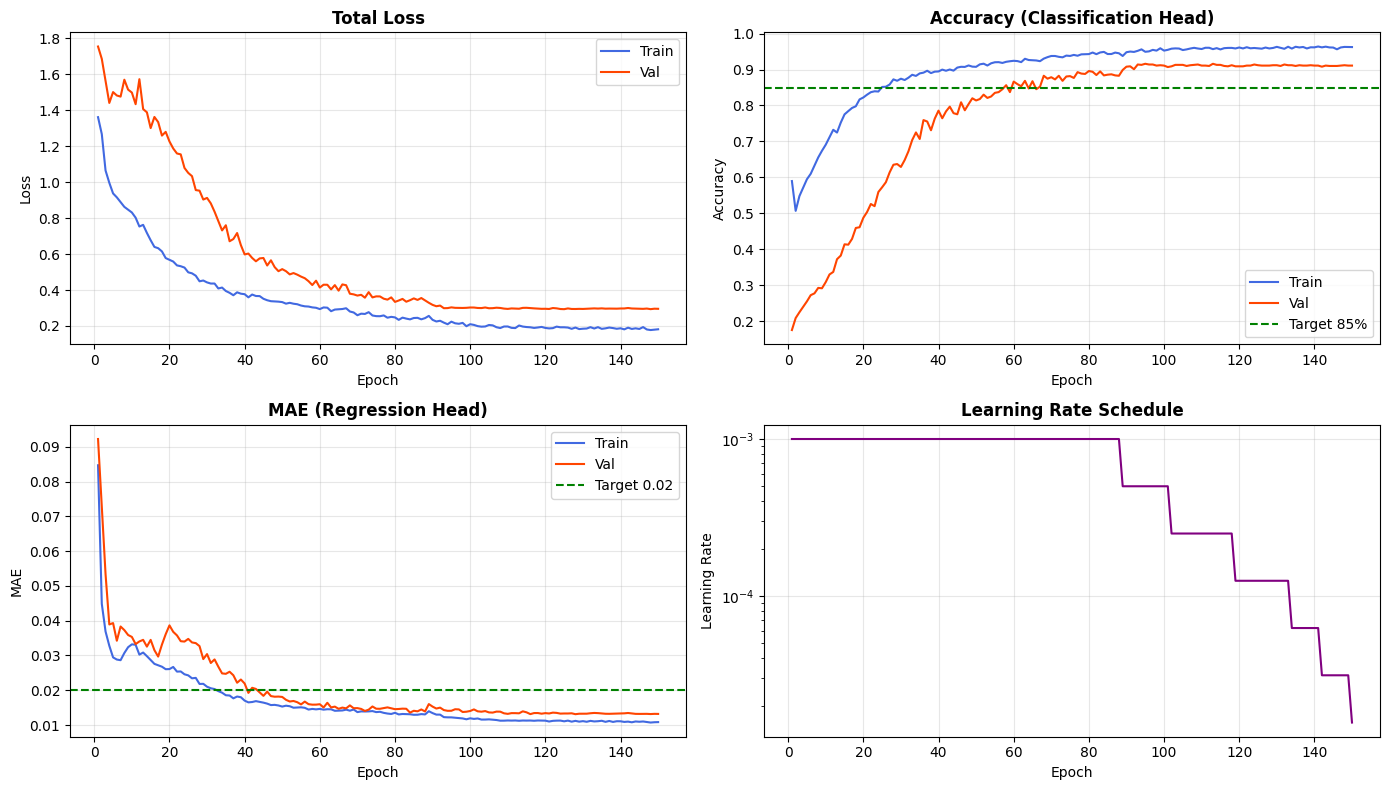

In [ ]:
history_df = pd.DataFrame(training_history)
history_df.to_csv('training_history.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Loss
axes[0,0].plot(history_df['epoch'], history_df['train_loss'], label='Train', color='royalblue')
axes[0,0].plot(history_df['epoch'], history_df['val_loss'], label='Val', color='orangered')
axes[0,0].set_title('Total Loss', fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Accuracy
axes[0,1].plot(history_df['epoch'], history_df['train_acc'], label='Train', color='royalblue')
axes[0,1].plot(history_df['epoch'], history_df['val_acc'], label='Val', color='orangered')
axes[0,1].axhline(0.85, ls='--', color='green', label='Target 85%')
axes[0,1].set_title('Accuracy (Classification Head)', fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# MAE
axes[1,0].plot(history_df['epoch'], history_df['train_mae'], label='Train', color='royalblue')
axes[1,0].plot(history_df['epoch'], history_df['val_mae'], label='Val', color='orangered')
axes[1,0].axhline(0.02, ls='--', color='green', label='Target 0.02')
axes[1,0].set_title('MAE (Regression Head)', fontweight='bold')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('MAE')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# Learning Rate
axes[1,1].plot(history_df['epoch'], history_df['lr'], color='purple')
axes[1,1].set_title('Learning Rate Schedule', fontweight='bold')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Learning Rate')
axes[1,1].set_yscale('log'); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
plt.show()

### Fase 5.2 — Evaluasi Final pada Test Set

Test set tidak pernah dilihat model selama training. Inilah angka final untuk laporan.

**Target yang harus dicapai:**
- Accuracy ≥ 85%
- MAE ≤ 0.02

In [ ]:
# Prediksi test set
pred_cls_prob, pred_reg = model.predict(X_te_s, verbose=0)
pred_cls_label = np.argmax(pred_cls_prob, axis=1)

# Metrics
test_acc = accuracy_score(ycls_te, pred_cls_label)
test_mae = mean_absolute_error(yreg_te, pred_reg.flatten())
test_f1  = f1_score(ycls_te, pred_cls_label, average='macro')

print('=' * 60)
print(f'         HASIL FINAL — TEST SET ({len(ycls_te)} samples)')
print('=' * 60)
print(f'Accuracy (Risk Class) : {test_acc*100:.2f}%   | Target >= 85%   | {"TERCAPAI" if test_acc>=0.85 else "BELUM"}')
print(f'MAE (Exam Score)      : {test_mae:.4f}     | Target <= 0.02 | {"TERCAPAI" if test_mae<=0.02 else "BELUM"}')
print(f'F1-Score (Macro)      : {test_f1:.4f}')
print(f'MAE skala asli        : {test_mae*100:.2f} poin (skala 0-100)')
print('=' * 60)

         HASIL FINAL — TEST SET (992 samples)
Accuracy (Risk Class) : 90.83%   | Target >= 85%   | TERCAPAI
MAE (Exam Score)      : 0.0153     | Target <= 0.02 | TERCAPAI
F1-Score (Macro)      : 0.5697
MAE skala asli        : 1.53 poin (skala 0-100)


### Fase 5.3 — Classification Report (Per-Class Metrics)

In [ ]:
print('Classification Report (Test Set):')
print('-' * 60)
print(classification_report(
    ycls_te, pred_cls_label,
    target_names=['Low', 'Medium', 'High'],
    digits=4
))

Classification Report (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

         Low     0.7345    0.7975    0.7647       163
      Medium     0.9472    0.9414    0.9443       819
        High     0.0000    0.0000    0.0000        10

    accuracy                         0.9083       992
   macro avg     0.5605    0.5796    0.5697       992
weighted avg     0.9027    0.9083    0.9052       992



### Fase 5.4 — Confusion Matrix

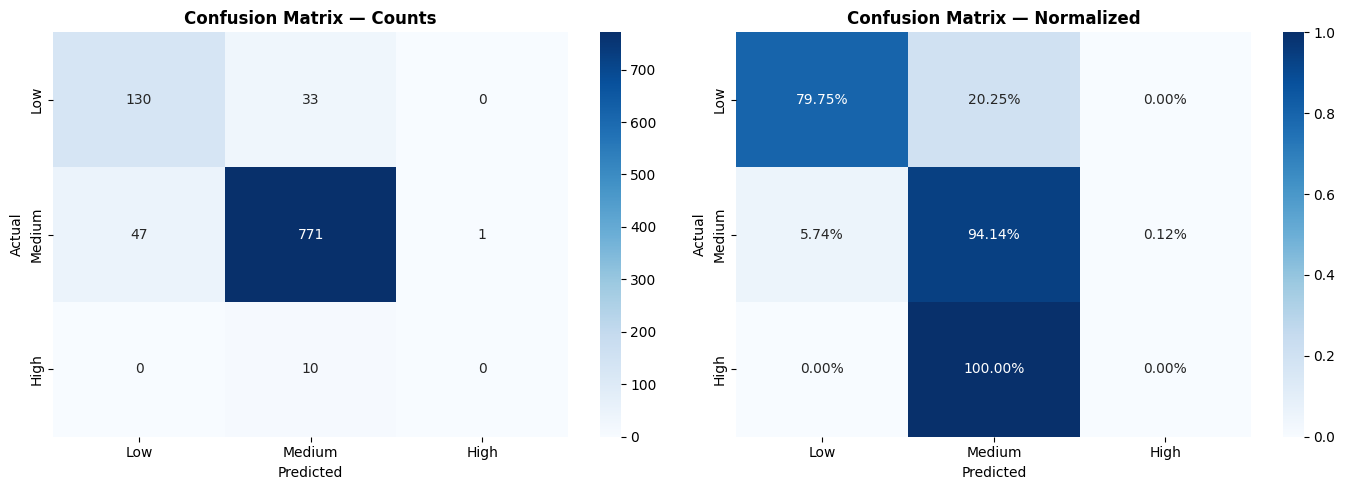

In [ ]:
cm = confusion_matrix(ycls_te, pred_cls_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
axes[1].set_title('Confusion Matrix — Normalized', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### Fase 5.5 — Regression Head Scatter Plot

Cek seberapa dekat prediksi `exam_score` dengan nilai sebenarnya.

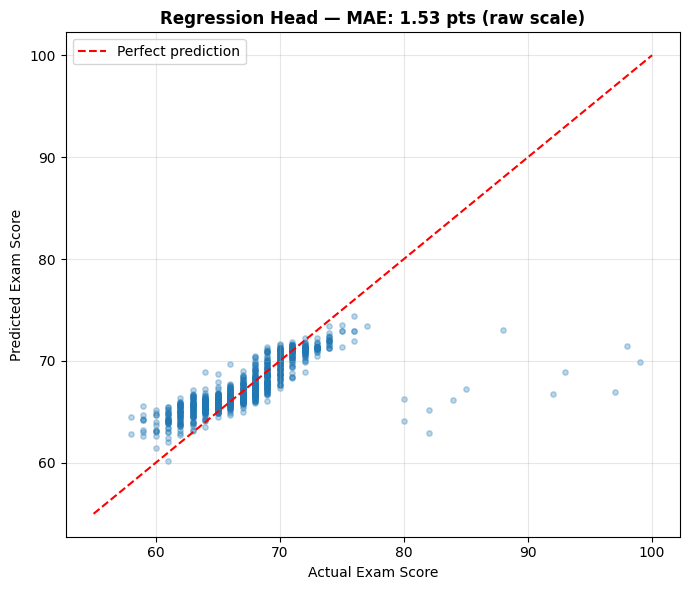

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(yreg_te * 100, pred_reg.flatten() * 100, alpha=0.3, s=15)
plt.plot([55, 100], [55, 100], 'r--', label='Perfect prediction')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title(f'Regression Head — MAE: {test_mae*100:.2f} pts (raw scale)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('regression_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

### Fase 5.6 — Save Model ke Format `.keras`

Format `.keras` adalah format modern Keras 3 yang **production-ready** dan kompatibel dengan Flask/FastAPI backend.

In [ ]:
MODEL_PATH = 'edupredict_multioutput.keras'
model.save(MODEL_PATH)
print(f'Model disimpan: {MODEL_PATH}')

Model disimpan: edupredict_multioutput.keras


### Fase 5.7 — Save Preprocessing Artifacts

Saat inference nanti, model perlu scaler dan encoder yang SAMA seperti saat training. Jadi harus disimpan.

In [ ]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)
with open('risk_map.pkl', 'wb') as f:
    pickle.dump(RISK_MAP, f)

print('Preprocessing artifacts disimpan:')
print('  - scaler.pkl')
print('  - label_encoders.pkl')
print('  - feature_cols.pkl')
print('  - risk_map.pkl')

Preprocessing artifacts disimpan:
  - scaler.pkl
  - label_encoders.pkl
  - feature_cols.pkl
  - risk_map.pkl


### Fase 5.8 — Verifikasi Reload Model

Pastikan model bisa di-load kembali dengan benar.

In [ ]:
loaded_model = keras.models.load_model(MODEL_PATH)
test_pred_cls, test_pred_reg = loaded_model.predict(X_te_s[:3], verbose=0)

print('Verifikasi load model — prediksi 3 sample pertama dari test set:')
for i in range(3):
    cls_idx = np.argmax(test_pred_cls[i])
    cls_name = ['Low','Medium','High'][cls_idx]
    actual_cls = ['Low','Medium','High'][ycls_te[i]]
    print(f'  Sample {i+1}: predicted={cls_name} ({test_pred_cls[i][cls_idx]*100:.1f}%), '
          f'actual={actual_cls}, score_pred={test_pred_reg[i][0]*100:.1f}')

Verifikasi load model — prediksi 3 sample pertama dari test set:
  Sample 1: predicted=Low (89.2%), actual=Low, score_pred=71.5
  Sample 2: predicted=Medium (98.9%), actual=Medium, score_pred=65.9
  Sample 3: predicted=Medium (96.9%), actual=Medium, score_pred=66.2


---

# FASE 6 — Integrasi Model ke Backend API
> **Project Plan:** 5/12/2026 – 5/18/2026 | Development

Fase ini menyiapkan kode inference yang akan dipakai oleh tim Full-Stack (Andhika & Nur Ayu) untuk mengintegrasikan model ke Flask backend.

**Output utama Fase 6:** fungsi `predict_student_risk()` yang siap di-adaptasi sebagai endpoint Flask/FastAPI.

### Fase 6.1 — Define `predict_student_risk()` Function

Fungsi inference sederhana yang menerima data siswa dalam bentuk dict (sesuai format yang akan dikirim dari frontend) dan mengembalikan prediksi lengkap.

In [ ]:
def predict_student_risk(student_data, model, scaler, label_encoders, feature_cols, risk_map):
    """
    Predict academic risk untuk satu siswa.

    Args:
        student_data    : dict dengan key sesuai feature_cols
                          (kolom kategorikal dalam bentuk string asli, contoh 'Medium')
        model           : model Keras yang sudah di-load
        scaler          : StandardScaler yang sudah di-fit saat training
        label_encoders  : dict {col_name: LabelEncoder}
        feature_cols    : list urutan kolom input
        risk_map        : dict {'Low':0, 'Medium':1, 'High':2}

    Returns:
        dict dengan key:
            - risk_category        : str ('Low' / 'Medium' / 'High')
            - confidence           : float [0,1]
            - probabilities        : dict per class
            - predicted_exam_score : float [0,100]
    """
    # 1. Build DataFrame
    df_input = pd.DataFrame([student_data])

    # 2. Encode kolom kategorikal pakai encoder yang SAMA dari training
    for col, le in label_encoders.items():
        if col in df_input.columns:
            df_input[col] = le.transform(df_input[col].astype(str))

    # 3. Extract feature dalam urutan yang benar & scale
    X_input  = df_input[feature_cols].values.astype(np.float32)
    X_scaled = scaler.transform(X_input)

    # 4. Predict (multi-output: keduanya didapat sekaligus)
    pred_cls_prob, pred_reg = model.predict(X_scaled, verbose=0)

    # 5. Decode hasil
    inv_risk_map = {v: k for k, v in risk_map.items()}
    cls_idx = int(np.argmax(pred_cls_prob[0]))

    return {
        'risk_category':        inv_risk_map[cls_idx],
        'confidence':           float(pred_cls_prob[0][cls_idx]),
        'probabilities':        {inv_risk_map[i]: float(pred_cls_prob[0][i]) for i in range(3)},
        'predicted_exam_score': float(pred_reg[0][0] * 100),
    }


print('Function predict_student_risk() siap')

Function predict_student_risk() siap


### Fase 6.2 — Contoh Penggunaan Inference

Demo memanggil fungsi dengan satu sampel siswa.

In [ ]:
# Contoh data siswa (dalam bentuk yang akan diterima dari frontend)
sample_student = {
    'Hours_Studied':            20,
    'Attendance':               75,
    'Parental_Involvement':     'Medium',
    'Access_to_Resources':      'Medium',
    'Sleep_Hours':              7,
    'Previous_Scores':          65,
    'Motivation_Level':         'Low',
    'Internet_Access':          'Yes',
    'Tutoring_Sessions':        1,
    'Family_Income':            'Medium',
    'Teacher_Quality':          'Medium',
    'Peer_Influence':           'Neutral',
    'Physical_Activity':        3,
    'Parental_Education_Level': 'High School',
}

result = predict_student_risk(
    sample_student,
    loaded_model, scaler, label_encoders, FEATURE_COLS, RISK_MAP
)

print('Hasil prediksi:')
print(f'  Risk Category    : {result["risk_category"]}')
print(f'  Confidence       : {result["confidence"]*100:.1f}%')
print(f'  Predicted Score  : {result["predicted_exam_score"]:.1f}')
print(f'  Probabilities    :')
for k, v in result['probabilities'].items():
    print(f'    {k:7s}: {v*100:.1f}%')

Hasil prediksi:
  Risk Category    : Medium
  Confidence       : 98.7%
  Predicted Score  : 64.9
  Probabilities    :
    Low    : 1.2%
    Medium : 98.7%
    High   : 0.1%


### Fase 6.3 — Snippet Hand-off untuk Tim Full-Stack

Code template untuk Andhika & Nur Ayu di-adaptasi sebagai Flask endpoint:

```python
from flask import Flask, request, jsonify
import keras
import pickle

# Load model & artifacts (sekali di startup)
model = keras.models.load_model('edupredict_multioutput.keras')
with open('scaler.pkl','rb') as f:           scaler = pickle.load(f)
with open('label_encoders.pkl','rb') as f:   label_encoders = pickle.load(f)
with open('feature_cols.pkl','rb') as f:     feature_cols = pickle.load(f)
with open('risk_map.pkl','rb') as f:         risk_map = pickle.load(f)

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    student_data = request.json
    result = predict_student_risk(
        student_data, model, scaler, label_encoders, feature_cols, risk_map
    )
    return jsonify(result)

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
```

File yang perlu di-share ke backend:
- `edupredict_multioutput.keras`
- `scaler.pkl`
- `label_encoders.pkl`
- `feature_cols.pkl`
- `risk_map.pkl`

---

# FASE 7 — Optimasi & Monitoring
> **Project Plan:** 5/19/2026 – 5/25/2026 | Development

Fase ini fokus pada **monitoring model di production** dan **optimasi lanjutan** jika performa belum optimal.

### Fase 7.1 — Akses TensorBoard (Monitoring)

TensorBoard sudah di-setup di Fase 4.7 dan log otomatis di-write per epoch saat training. Untuk visualisasi:

```bash
tensorboard --logdir logs/edupredict
```

Buka browser ke `http://localhost:6006`. Di TensorBoard akan terlihat:

| Plot | Insight |
|------|---------|
| **Loss** (train vs val) | Cek apakah ada overfitting (gap melebar) |
| **Accuracy** (train vs val) | Konvergensi akurasi terhadap target 85% |
| **MAE** (train vs val) | Konvergensi MAE terhadap target 0.02 |
| **Learning Rate** | Lihat kapan LR scheduler aktif menurunkan LR |

**Untuk repository submission**: folder `logs/edupredict/` wajib ikut di-commit (sesuai requirement dicoding *"menyertakan log yang dihasilkan dalam repository akhir"*).

### Fase 7.2 — Tuning Tips (Optimasi Lanjutan)

Jika performa belum optimal, knob-knob yang bisa di-tune:

**1. `LAMBDA_REG` (Fase 4.2)** — knob terpenting untuk balance Accuracy vs MAE:
- Naikkan ke 8.0 atau 10.0 → MAE lebih kecil, tapi accuracy mungkin sedikit turun
- Turunkan ke 3.0 → accuracy naik, tapi MAE mungkin naik

**2. Arsitektur model (Fase 3.4)** — untuk underfitting:
- Perbesar layer pertama (256 → 384 atau 512)
- Tambah satu layer dense lagi
- Turunkan L2 regularization (5e-5 → 1e-5)

**3. Dropout (Fase 3.4)** — untuk overfitting:
- Naikkan dropout rate (0.4 → 0.5)
- Tambah dropout sebelum output head

**4. Learning Rate (Fase 4.3)** — untuk konvergensi:
- Coba LR awal 5e-4 (lebih lambat tapi stabil) atau 2e-3 (lebih cepat tapi noisy)

**5. SMOTE strategy (Fase 3.3)** — untuk class imbalance:
- Coba `sampling_strategy='auto'` (default) vs custom dict
- Atau ganti dengan ADASYN dari `imblearn`

---

# FASE 8 — Testing Model & Documentation
> **Project Plan:** 5/26/2026 – 6/1/2026 | Reporting

Fase finalisasi: dokumentasi semua deliverable, checklist pencapaian tugas, dan persiapan untuk laporan akhir.

### Fase 8.1 — Checklist Pencapaian Tugas

| Fase Project Plan | Status | Cell Notebook |
|------|--------|------|
| Fase 1 — Setup Environment TensorFlow/Keras | Selesai | Fase 1.1 – 1.2 |
| Fase 2 — Eksplorasi & Seleksi Fitur Dataset | Selesai | Fase 2.1 – 2.4 |
| Fase 3 — Training Model (Multi-Output Final) | Selesai | Fase 3.1 – 3.6 |
| Fase 4 — Custom Callback & Hypertuning | Selesai | Fase 4.1 – 4.8 |
| Fase 5 — Evaluasi & Ekspor Model | Selesai | Fase 5.1 – 5.8 |
| Fase 6 — Integrasi Model ke Backend API | Selesai (hand-off ke FS) | Fase 6.1 – 6.3 |
| Fase 7 — Optimasi & Monitoring | Selesai | Fase 7.1 – 7.2 |
| Fase 8 — Testing & Documentation | Selesai (notebook ini) | Fase 8.1 – 8.3 |

### Fase 8.2 — Daftar Output Files

Semua file yang dihasilkan notebook ini:

| File | Untuk |
|------|-------|
| `edupredict_multioutput.keras` | Model — di-load oleh tim Full-Stack via Flask |
| `scaler.pkl` | Normalisasi input saat inference |
| `label_encoders.pkl` | Encoding fitur kategorikal saat inference |
| `feature_cols.pkl` | Urutan kolom input |
| `risk_map.pkl` | Mapping label klasifikasi |
| `training_log.csv` | Log dari Custom Callback (Fase 4.1) |
| `training_history.csv` | Log dari Custom Training Loop (Fase 4.8) |
| `logs/edupredict/` | TensorBoard logs (Fase 4.7) |
| `model_architecture.png` | Visualisasi arsitektur model |
| `training_history.png` | Plot 4-panel training metrics |
| `confusion_matrix.png` | Confusion matrix test set |
| `regression_scatter.png` | Scatter plot regression head |

### Fase 8.3 — Mapping ke Requirement Dicoding

Notebook ini juga sekaligus memenuhi semua persyaratan AI Engineer dari dicoding:

| Requirement Dicoding | Implementasi di Notebook |
|---------------------|--------------------------|
| Model dengan **TensorFlow Functional API** | Fase 3.4 (multi-output architecture) |
| **Custom Component** (Custom Callback) | Fase 4.1 (`EduPredictCallback`) |
| Custom training loop dengan **`tf.GradientTape`** | Fase 4.4 (`train_step`) + Fase 4.5 (`val_step`) + Fase 4.8 (main loop) |
| Integrasi **TensorBoard** | Fase 4.7 (writers) + Fase 4.8 (logging dalam loop) |
| Akurasi ≥ 85% dan MAE ≤ 0.02 | Fase 5.2 (test set evaluation) |
| Ekspor model format **`.keras`** | Fase 5.6 (save) |
| **Kode inference sederhana** | Fase 6.1 (`predict_student_risk()`) |

**Larangan dicoding yang dihindari:**
- Bukan TensorFlow Hub / model pre-trained
- Bukan ChatGPT/Gemini API
- Bukan AutoML — arsitektur custom from scratch
- `Exam_Score` sebagai TARGET (output), bukan input feature → aman dari data leakage